In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, t

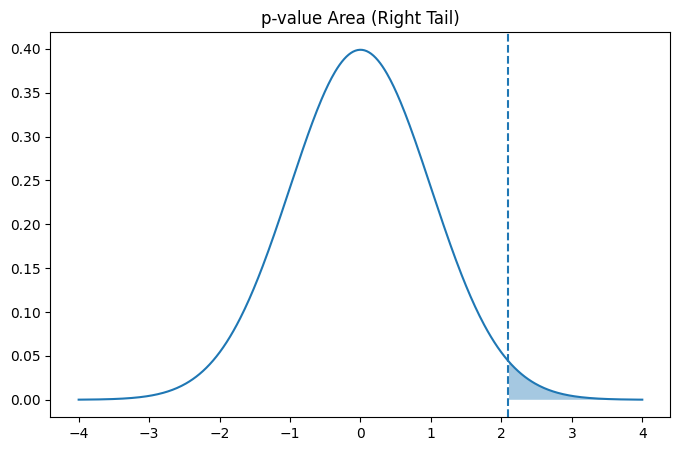

In [ ]:
'''
The p-value is the shaded area beyond the test statistic.

It represents how extreme the observation is.
'''

z_score = 2.1

x = np.linspace(-4,4,500)
y = norm.pdf(x)

plt.figure(figsize=(8,5))
plt.plot(x,y)
plt.fill_between(x, y, where=(x>=z_score), alpha=0.4)

plt.axvline(z_score, linestyle="--")
plt.title("p-value Area (Right Tail)")
plt.show()


## Step 4: The Test Statistic

To measure how extreme the data is, we compute a test statistic.

This depends on the situation:

- z-test → known population variance
- t-test → unknown population variance (most common)
- chi-square → categorical data
- ANOVA → multiple groups

For comparing means in data science, we often use a **t-test**.


### Z-Test vs T-Test  
*A Story About What We Know… and What We Don’t*

Imagine you want to test whether a new teaching method improves exam scores. You collect a sample of students and compute the mean. Now you must ask:

> Do we know the population standard deviation?

If YES → use Z-test  
If NO → use T-test  

In real life, we almost never know the true population standard deviation. So data scientists usually use the **t-test**.

## Key Differences

| Feature | Z-Test | T-Test |
|------|------|------|
| Population standard deviation known? | Yes | No |
| Sample size | Usually large | Any size |
| Distribution | Normal | t-distribution |
| Shape | Fixed | Wider tails (more uncertainty) |
| Real-world usage | Rare | Very common |

Why wider tails? Because estimating variability from a sample introduces uncertainty.



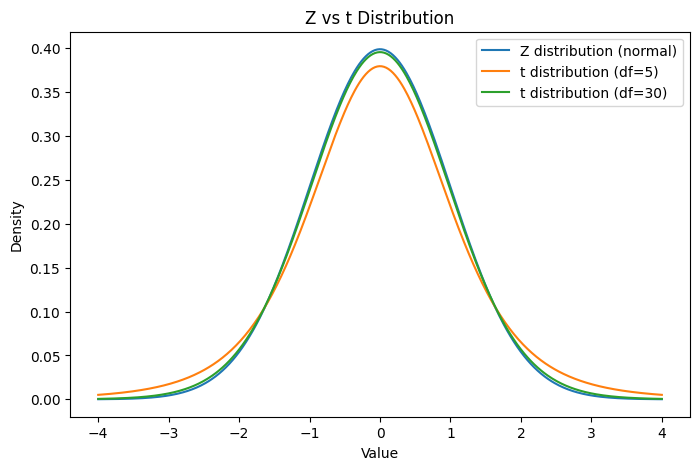

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, t

x = np.linspace(-4,4,500)

plt.figure(figsize=(8,5))
plt.plot(x, norm.pdf(x), label="Z distribution (normal)")
plt.plot(x, t.pdf(x, df=5), label="t distribution (df=5)")
plt.plot(x, t.pdf(x, df=30), label="t distribution (df=30)")
plt.title("Z vs t Distribution")
plt.xlabel("Value")
plt.ylabel("Density")
plt.legend()
plt.show()


Notice:
- Small sample → thicker tails → more uncertainty  
- Large sample → t looks like normal  

As sample size increases, t-test becomes similar to z-test.

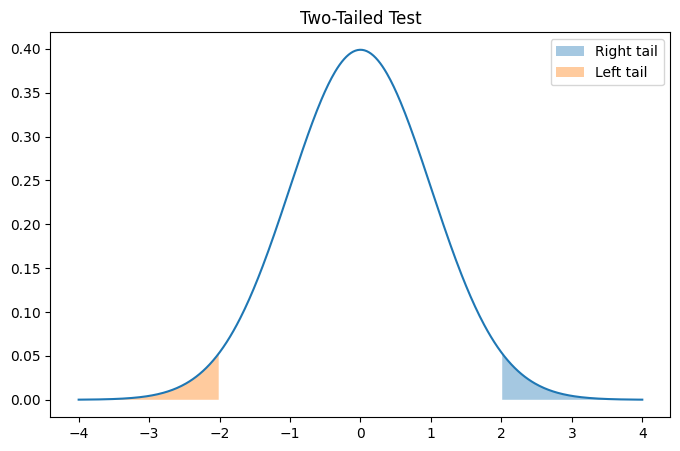

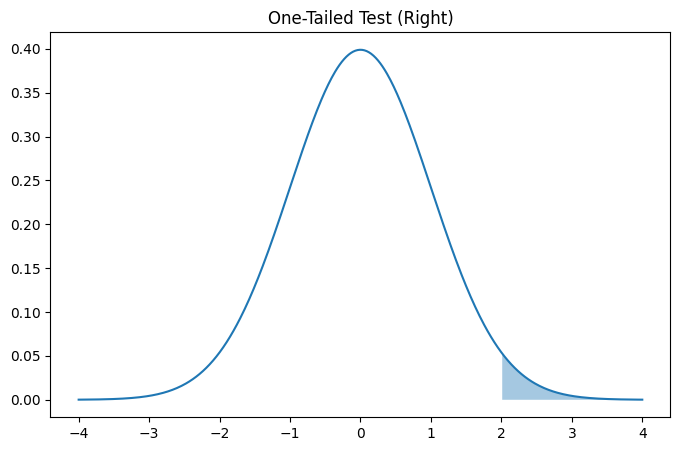

In [ ]:
# Interactive Tail Visualization

z = 2.0
x = np.linspace(-4,4,500)
y = norm.pdf(x)

plt.figure(figsize=(8,5))
plt.plot(x,y)

# right tail
plt.fill_between(x, y, where=(x>=z), alpha=0.4, label="Right tail")

# left tail
plt.fill_between(x, y, where=(x<=-z), alpha=0.4, label="Left tail")

plt.title("Two-Tailed Test")
plt.legend()
plt.show()


z = 2.0
x = np.linspace(-4,4,500)
y = norm.pdf(x)

plt.figure(figsize=(8,5))
plt.plot(x,y)
plt.fill_between(x, y, where=(x>=z), alpha=0.4)

plt.title("One-Tailed Test (Right)")
plt.show()

**Notice:**
- Two-tailed → split probability across both ends  
- One-tailed → all probability in one direction  

One-tailed tests are more powerful but must be justified BEFORE analysis.

## Example Walkthrough

Let’s return to the food delivery company.

Data:

- Old system mean = 24.10
- New system mean = 25.30
- Sample size = 200 users
- Sample standard deviation = 5

We run a t-test. Suppose we get: p-value = 0.02


**Interpretation:** If the new system had no effect, there is only a **2% chance** of seeing this difference.

That is small. So we reject the null hypothesis.

**Conclusion:** Evidence suggests the new recommendation system increases order value.



## What Hypothesis Testing Does NOT Tell You

*Very important.* Rejecting the null does NOT prove something is true with certainty. It only means:

> The data is unlikely under the null assumption.

Also:

- Small p-value ≠ large impact
- Statistical significance ≠ practical importance

A tiny improvement can still be statistically significant if sample size is huge.

Always check **effect size** too.



## Two Common Mistakes (Errors)

Because decisions are made under uncertainty, mistakes can happen.

### **Type I Error**: False Alarm
Rejecting a true null.

Example: We think the new system works… but it doesn’t.

Probability = α (e.g., 5%)



### **Type II Error:** Missed Detection
Failing to reject a false null. Example: The system really works… but we fail to detect it.


#### Visualizing Type I and Type II Errors

Understanding statistical errors becomes much easier when we see them visually. The graph below shows two distributions:

- The **null hypothesis distribution**
- The **alternative hypothesis distribution**

Because these two distributions overlap, mistakes are possible.

- **Type I error (α)** — rejecting a true null hypothesis (**false positive**)
- **Type II error (β)** — failing to reject a false null hypothesis (**false negative**)

The shaded regions in the figure show where these errors occur.Everything else represents correct decisions.

<center>

<img src="https://static.wingify.com/gcp/uploads/sites/3/2020/12/graphical-representation-of-type-1-and-type-2-errors.png" width="450">
<br>
<b>Figure:</b> Graphical representation of hypothesis testing errors.The blue curve shows the distribution when the <b>null hypothesis (H₀)</b> is true, and the green curve shows the distribution when the <b>alternative hypothesis (H₁)</b> is true.  
The vertical line indicates the <b>critical value</b>. The shaded area under H₀ beyond this boundary represents the <b>Type I error (α)</b>, while the shaded area under H₁ on the non-rejection side represents the <b>Type II error (β)</b>.  

<b>Source:</b> Wingify (VWO).

<!-- <b>Figure:</b> Graphical representation of hypothesis testing errors. The blue curve represents the sampling distribution when the <b>null hypothesis (H₀) is true</b>, and the green curve represents the distribution when the <b>alternative hypothesis (H₁)</b> is true. The vertical line marks the <b>decision boundary (critical value)</b> separating the rejection region from the non-rejection region.  The shaded area on the right under the null distribution represents the <b>Type I error (α)</b>, rejecting a true null hypothesis. The shaded area on the left under the alternative distribution represents the <b> Type II error (β)</b>, failing to reject a false null hypothesis. Source. Wingify (VWO). -->
<br>

</center>





## The Full Hypothesis Testing Workflow

1. State null and alternative hypotheses  
2. Choose significance level (α)  
3. Compute test statistic  
4. Calculate p-value  
5. Compare with α  
6. Make decision  
7. Interpret in real context  



## Why This Matters in Data Science

Hypothesis testing appears everywhere:

- A/B testing products
- Evaluating ML model improvements
- Medical research
- Marketing campaigns
- Feature impact analysis
- Policy evaluation

Any time we ask:

> Did this change actually cause an effect?

We use hypothesis testing.


## Reflection Questions

Pause and think:

1. Why don’t we try to prove the alternative hypothesis directly?
2. Why do we need a significance threshold?
3. Can a result be statistically significant but not useful?



## Final Intuition

Hypothesis testing is not just math. It is a philosophy of evidence We begin with skepticism. We demand strong proof. We accept uncertainty. We make decisions anyway. That is the essence of data science.

**Final Business Interpretation**: We answer three questions:

1. Is the difference statistically real?  
2. How large is the difference?  
3. Is it worth implementing?

> Data science is not just testing: it is decision making.

In the next section, we will implement a **t-test in Python** and run a real A/B experiment.